In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

Reading the Evaluation data by Pathologist

In [2]:
evaluator_id = 'evaluator3'
eval_data_path = f"input/{evaluator_id}/pathvqa_eval_data.csv"
eval_data = pd.read_csv(eval_data_path)
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question,OE_Correct_Answer,Evaluation OE_Correct_Answer\n(Benchmark 1),Unnamed: 6,CE_Question,CE_Correct_Answer,Evaluation CE_Correct_Answer\n(Benchmark 3)
0,NaN,NaN,NaN,NaN,NaN,Knowledge Interpretation/Deduction,Visual Grounding,NaN,NaN,Visual Grounding/Reasoning
1,1.0,train_0294,https://drive.google.com/file/d/14N0WpDAbMCRBK...,NaN,NaN,NaN,NaN,Is the embolus not prominent in this case?,no,-1
2,2.0,train_0363,https://drive.google.com/file/d/1gJXgy1jsNhMjv...,NaN,NaN,NaN,NaN,Are collapsed tubules outlined by wavy basemen...,yes,2
3,3.0,train_0697,https://drive.google.com/file/d/1Uu_Wpw9HqHBXR...,NaN,NaN,NaN,NaN,Are small nests of epithelial cells and myxoid...,yes,-1
4,4.0,train_0627,https://drive.google.com/file/d/1NyfVTxM2DXQGZ...,NaN,NaN,NaN,NaN,What is orderly differentiation of squamous ce...,no,-1


Creating the directory structure to save Graphs and Output for Each Evaluator

In [3]:
output_data_path = f"output/{evaluator_id}"
os.makedirs(output_data_path, exist_ok=True)

Renaming some columns

In [4]:
eval_data = eval_data.rename(columns={'Evaluation OE_Correct_Answer\n(Benchmark 1)': 'OE_Correct_Answer_Know_Inter',
                                        'Unnamed: 6': 'OE_Correct_Answer_Vis_Ground',
                                        'Evaluation CE_Correct_Answer\n(Benchmark 3)': 'CE_Correct_Answer_Vis_Ground',
                                        })

eval_data = eval_data.drop(index=0) #dropping the first row which contains the benchmark names
eval_data.head()

,CASE_ID,Image_ID,Image_URL,OE_Question,OE_Correct_Answer,OE_Correct_Answer_Know_Inter,OE_Correct_Answer_Vis_Ground,CE_Question,CE_Correct_Answer,CE_Correct_Answer_Vis_Ground
1,1.0,train_0294,https://drive.google.com/file/d/14N0WpDAbMCRBK...,NaN,NaN,NaN,NaN,Is the embolus not prominent in this case?,no,-1
2,2.0,train_0363,https://drive.google.com/file/d/1gJXgy1jsNhMjv...,NaN,NaN,NaN,NaN,Are collapsed tubules outlined by wavy basemen...,yes,2
3,3.0,train_0697,https://drive.google.com/file/d/1Uu_Wpw9HqHBXR...,NaN,NaN,NaN,NaN,Are small nests of epithelial cells and myxoid...,yes,-1
4,4.0,train_0627,https://drive.google.com/file/d/1NyfVTxM2DXQGZ...,NaN,NaN,NaN,NaN,What is orderly differentiation of squamous ce...,no,-1
5,5.0,train_0627,https://drive.google.com/file/d/1NyfVTxM2DXQGZ...,NaN,NaN,NaN,NaN,Is the transmural light area in the posterolat...,no,-1


Converting all the evaluation columns from Str to Int

In [5]:
eval_data = eval_data.astype({'OE_Correct_Answer_Know_Inter': 'float',
                                'OE_Correct_Answer_Vis_Ground': 'float',
                                'CE_Correct_Answer_Vis_Ground': 'float',})

eval_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 132 entries, 1 to 132
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   CASE_ID                       132 non-null    float64
 1   Image_ID                      132 non-null    str    
 2   Image_URL                     132 non-null    str    
 3   OE_Question                   122 non-null    str    
 4   OE_Correct_Answer             122 non-null    str    
 5   OE_Correct_Answer_Know_Inter  122 non-null    float64
 6   OE_Correct_Answer_Vis_Ground  122 non-null    float64
 7   CE_Question                   10 non-null     str    
 8   CE_Correct_Answer             10 non-null     str    
 9   CE_Correct_Answer_Vis_Ground  10 non-null     float64
dtypes: float64(4), str(6)
memory usage: 10.4 KB


Finding Missing Evaluations or Wrong Evaluations

In [6]:
OE_Correct_Answer_1_Know_Inter_Missing = eval_data[(eval_data['OE_Question'].notnull()) & (eval_data['OE_Correct_Answer'].notnull()) & ((eval_data['OE_Correct_Answer_Know_Inter'].isnull()) | (~eval_data['OE_Correct_Answer_Know_Inter'].isin([-1,0,1,2])))]['Image_ID'].to_list()
OE_Correct_Answer_1_Vis_Ground_Missing = eval_data[(eval_data['OE_Question'].notnull()) & (eval_data['OE_Correct_Answer'].notnull()) & ((eval_data['OE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['OE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()
CE_Correct_Answer_Vis_Ground_Missing = eval_data[(eval_data['CE_Question'].notnull()) & (eval_data['CE_Correct_Answer'].notnull()) & ((eval_data['CE_Correct_Answer_Vis_Ground'].isnull()) | (~eval_data['CE_Correct_Answer_Vis_Ground'].isin([-1,0,1,2])))]['Image_ID'].to_list()

print(f"OE_Correct_Answer_1_Know_Inter_Missing: {OE_Correct_Answer_1_Know_Inter_Missing}")
print(f"OE_Correct_Answer_1_Vis_Ground_Missing: {OE_Correct_Answer_1_Vis_Ground_Missing}")
print(f"CE_Correct_Answer_Vis_Ground_Missing: {CE_Correct_Answer_Vis_Ground_Missing}")

OE_Correct_Answer_1_Know_Inter_Missing: []
OE_Correct_Answer_1_Vis_Ground_Missing: []
CE_Correct_Answer_Vis_Ground_Missing: []


#### Correct Answer

1

In [7]:
oe_correct_answer_know_inter_df = eval_data[eval_data['OE_Question'].notnull() & eval_data['OE_Correct_Answer'].notnull() & eval_data['OE_Correct_Answer_Know_Inter'].notnull()]
oe_correct_answer_know_inter_total = len(oe_correct_answer_know_inter_df)
oe_correct_answer_know_inter_eval_2 = len(oe_correct_answer_know_inter_df[oe_correct_answer_know_inter_df['OE_Correct_Answer_Know_Inter'] == 2])
oe_correct_answer_know_inter_eval_1 = len(oe_correct_answer_know_inter_df[oe_correct_answer_know_inter_df['OE_Correct_Answer_Know_Inter'] == 1])
oe_correct_answer_know_inter_eval_0 = len(oe_correct_answer_know_inter_df[oe_correct_answer_know_inter_df['OE_Correct_Answer_Know_Inter'] == 0])
oe_correct_answer_know_inter_eval_neg_1 = len(oe_correct_answer_know_inter_df[oe_correct_answer_know_inter_df['OE_Correct_Answer_Know_Inter'] == -1])

In [8]:
oe_correct_answer_vis_ground_df = eval_data[eval_data['OE_Question'].notnull() & eval_data['OE_Correct_Answer'].notnull() & eval_data['OE_Correct_Answer_Vis_Ground'].notnull()]
oe_correct_answer_vis_ground_total = len(oe_correct_answer_vis_ground_df)
oe_correct_answer_vis_ground_eval_2 = len(oe_correct_answer_vis_ground_df[oe_correct_answer_vis_ground_df['OE_Correct_Answer_Vis_Ground'] == 2])
oe_correct_answer_vis_ground_eval_1 = len(oe_correct_answer_vis_ground_df[oe_correct_answer_vis_ground_df['OE_Correct_Answer_Vis_Ground'] == 1])
oe_correct_answer_vis_ground_eval_0 = len(oe_correct_answer_vis_ground_df[oe_correct_answer_vis_ground_df['OE_Correct_Answer_Vis_Ground'] == 0])
oe_correct_answer_vis_ground_eval_neg_1 = len(oe_correct_answer_vis_ground_df[oe_correct_answer_vis_ground_df['OE_Correct_Answer_Vis_Ground'] == -1])


CE

In [9]:
ce_correct_answer_vis_ground_df = eval_data[eval_data['CE_Question'].notnull() & eval_data['CE_Correct_Answer'].notnull() & eval_data['CE_Correct_Answer_Vis_Ground'].notnull()]
ce_correct_answer_vis_ground_total = len(ce_correct_answer_vis_ground_df)
ce_correct_answer_vis_ground_eval_2 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 2])
ce_correct_answer_vis_ground_eval_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 1])
ce_correct_answer_vis_ground_eval_0 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == 0])
ce_correct_answer_vis_ground_eval_neg_1 = len(ce_correct_answer_vis_ground_df[ce_correct_answer_vis_ground_df['CE_Correct_Answer_Vis_Ground'] == -1])

Calculating the consolidated information all the correct questions/answers

In [10]:
correct_answer_que_type = [
                            'Open-Ended',
                            'Open-Ended',
                            'Close-Ended',
                        ]


correct_answer_benchmark_label = [
                                    'Knowledge Interpretation',
                                    'Visual Grounding',
                                    'Visual Grounding'
                                ]

correct_answer_total = [oe_correct_answer_know_inter_total,
                        oe_correct_answer_vis_ground_total,
                        ce_correct_answer_vis_ground_total]

correct_answer_eval_2 = [oe_correct_answer_know_inter_eval_2,
                        oe_correct_answer_vis_ground_eval_2,
                        ce_correct_answer_vis_ground_eval_2]

correct_answer_eval_1 = [oe_correct_answer_know_inter_eval_1,
                        oe_correct_answer_vis_ground_eval_1,
                        ce_correct_answer_vis_ground_eval_1]

correct_answer_eval_0 = [oe_correct_answer_know_inter_eval_0,
                        oe_correct_answer_vis_ground_eval_0,
                        ce_correct_answer_vis_ground_eval_0]

correct_answer_eval_neg_1 = [oe_correct_answer_know_inter_eval_neg_1,
                            oe_correct_answer_vis_ground_eval_neg_1,
                            ce_correct_answer_vis_ground_eval_neg_1]

correct_answer_eval_data = pd.DataFrame({'Total': correct_answer_total,
                                        'Level 2': correct_answer_eval_2,
                                        'Level 1': correct_answer_eval_1,
                                        'Level 0': correct_answer_eval_0,
                                        'Level -1': correct_answer_eval_neg_1}, index=[correct_answer_que_type, correct_answer_benchmark_label])

correct_answer_eval_data

Total  Level 2  Level 1  Level 0  \
Open-Ended  Knowledge Interpretation    122       61       32       13   
            Visual Grounding            122       64       26       17   
Close-Ended Visual Grounding             10        3        0        0   

                                      Level -1  
Open-Ended  Knowledge Interpretation        16  
            Visual Grounding                15  
Close-Ended Visual Grounding                 7

Save the Evaluation Data for correct answers

In [11]:
correct_answer_eval_data.to_pickle(os.path.join(output_data_path, 'pathvqa_correct_answer_eval_data.pkl'))

Open-Ended Correct Answers Graph

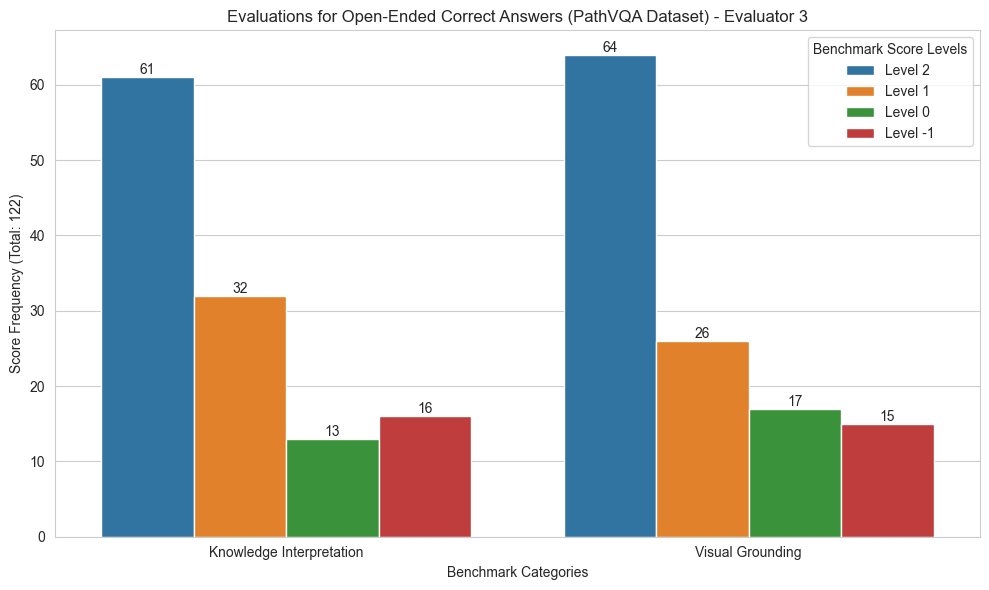

In [12]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).loc['Open-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Open-Ended Correct Answers (PathVQA Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[0]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_open_ended_correct_answers.png')
plt.show()

Close-Ended Correct Answers Graph

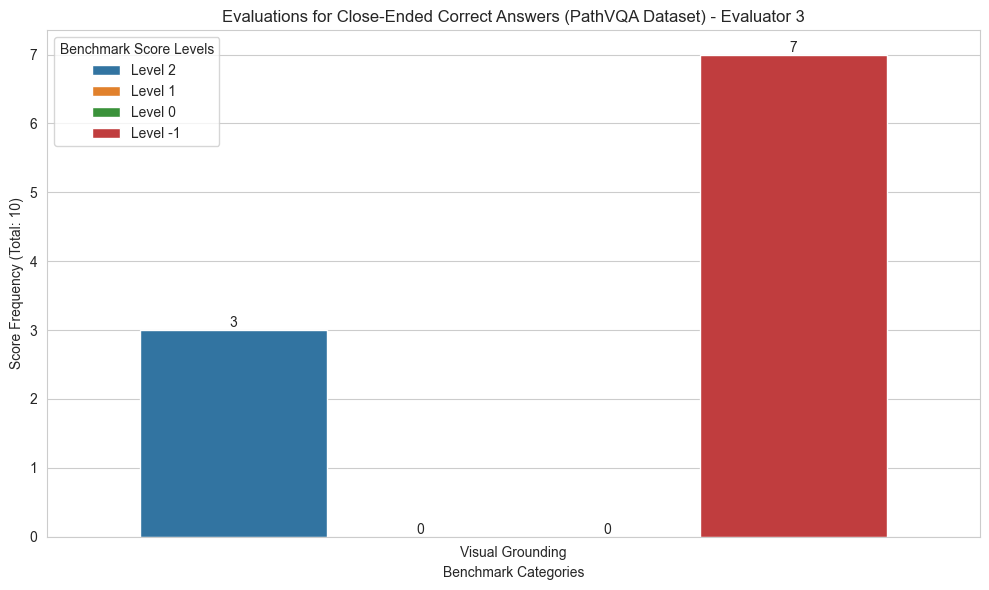

In [13]:
temp_data = correct_answer_eval_data.drop(columns=['Total']).loc['Close-Ended'].transpose().reset_index()
temp_data = temp_data.melt(id_vars='index', var_name='Column Names', value_name='Values')

sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=temp_data, x='Column Names', y='Values', hue='index')

for container in ax.containers:
    ax.bar_label(container)
plt.title(f'Evaluations for Close-Ended Correct Answers (PathVQA Dataset) - Evaluator {evaluator_id[-1]}')
plt.xlabel('Benchmark Categories')
plt.ylabel(f'Score Frequency (Total: {correct_answer_total[2]})')
plt.legend(title='Benchmark Score Levels')
plt.tight_layout()
plt.savefig(f'{output_data_path}/pathvqa_close_ended_correct_answers.png')
plt.show()